Dataset Shape: (50000, 20)
   user_id  age  gender country  account_age_months subscription_type  \
0  U100000   56    Male   India                  17          Standard   
1  U100001   46  Female     USA                  20          Standard   
2  U100002   32   Other     USA                  25             Basic   
3  U100003   60    Male  Canada                  37          Standard   
4  U100004   25    Male  Brazil                  23           Premium   

   monthly_fee payment_method primary_device  devices_used favorite_genre  \
0        15.99         PayPal         Laptop             1         Sci-Fi   
1        12.99         PayPal         Tablet             2    Documentary   
2        15.99         PayPal         Tablet             2         Comedy   
3        12.99         PayPal       Smart TV             3         Action   
4        12.99         PayPal         Mobile             3         Horror   

   avg_watch_time_minutes  watch_sessions_per_week  binge_watch_session

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Baseline Model Results
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.8046   0.000000  0.000000  0.000000
1        Decision Tree    0.6580   0.184867  0.220061  0.200935
2                  KNN    0.7734   0.212177  0.058854  0.092147


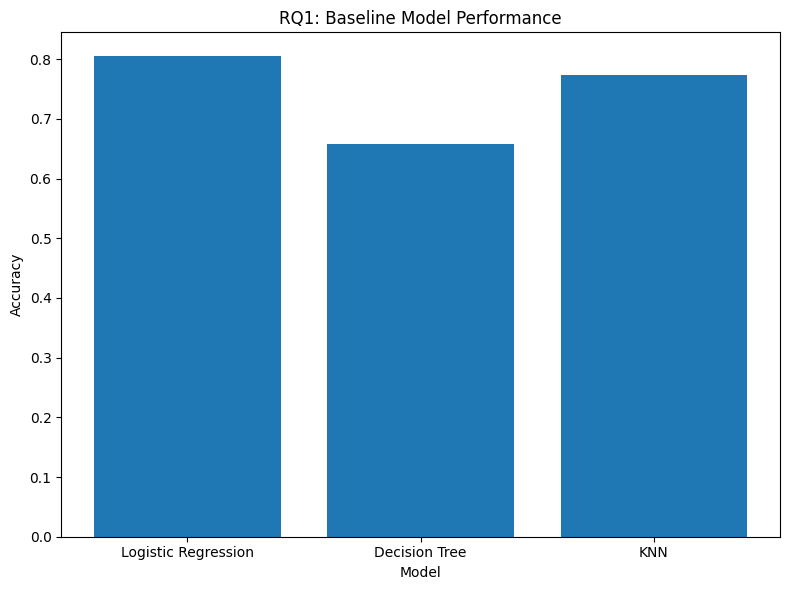


Files saved successfully:
RQ1_table.csv
RQ1_figure.pdf


In [1]:
# ==================================================
# RQ1: Baseline Performance
# Netflix User Churn Prediction
# ==================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


# ==================================================
# Step 1: Load Dataset
# ==================================================

df = pd.read_csv('/kaggle/input/datasets/sampath1092003/netflix-user-behavior-analysis-dataset/netflix_user_behavior_dataset.csv')

print("Dataset Shape:", df.shape)
print(df.head())


# ==================================================
# Step 2: Drop unnecessary column
# ==================================================

# user_id is just an identifier
df.drop('user_id', axis=1, inplace=True)


# ==================================================
# Step 3: Encode categorical columns
# ==================================================

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


# ==================================================
# Step 4: Split features and target
# ==================================================

X = df.drop('churned', axis=1)
y = df['churned']


# ==================================================
# Step 5: Train-Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==================================================
# Step 6: Define baseline models
# ==================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


# ==================================================
# Step 7: Train and evaluate
# ==================================================

results = []

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Save results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])


# ==================================================
# Step 8: Create results table
# ==================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print("\nBaseline Model Results")
print(results_df)


# ==================================================
# Step 9: Save table as CSV
# ==================================================

results_df.to_csv(
    '/kaggle/working/RQ1_table.csv',
    index=False
)


# ==================================================
# Step 10: Plot figure
# ==================================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("RQ1: Baseline Model Performance")

plt.tight_layout()


# ==================================================
# Step 11: Save figure as PDF
# ==================================================

plt.savefig(
    '/kaggle/working/RQ1_figure.pdf'
)

plt.show()


# ==================================================
# Step 12: Final confirmation
# ==================================================

print("\nFiles saved successfully:")
print("RQ1_table.csv")
print("RQ1_figure.pdf")